In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [5]:
nq = np.linspace(3, 51, num=17)
Re = (5 * 2**(nq/3 - 1))**(4/3)
scaling = 2**(4 * nq / 9)

print(np.int32(Re))

[       8       21       54      136      344      868     2188     5515
    13897    35020    88245   222365   560324  1411930  3557841  8965198
 22590885]


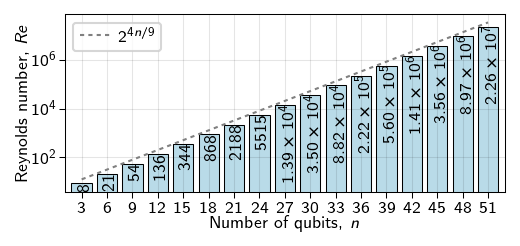

In [13]:
fig_width = 18/2.54
fig_height = 18/2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 7.4559/2.54 / fig_width
ax_height = 3/2.54 / fig_height

# 
ax = fig.add_axes([0, 0, ax_width, ax_height])
ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)
bars = ax.bar(nq, Re, width=2.4, color='#B9DBE8', edgecolor='black', linewidth=0.5, alpha=1)

for bar in bars:
    height = bar.get_height()
    h_int = np.int32(height)

    # 判断位数
    if abs(h_int) < 10**4:  # 低于 5 位
        label = f'{h_int}'
    else:  # ≥5 位，科学计数法，三位有效数字
        label = f'{h_int:.2e}'
        base, exp = label.split('e')
        label = rf'${base}\times 10^{{{int(exp)}}}$'

    plt.text(
        bar.get_x() + bar.get_width(),
        height,
        label,
        ha='right',
        va='top',
        rotation=90,
        fontsize=fontsize
    )
ax.plot(nq, 5 * scaling, linewidth=1, linestyle='--', dashes=(2, 2), color='gray', label=r'$2^{4n/9}$')
plt.yscale('log')
ax.legend(ncol=1, frameon=True, labelspacing=0.2, handlelength=1.8, handletextpad=0.5, bbox_to_anchor=(0, 1), loc='upper left', fontsize=fontsize)
plt.xlabel(r'Number of qubits, $n$', labelpad=0, size=fontsize)
plt.ylabel(r'Reynolds number, $\mathit{Re}$', labelpad=1, size=fontsize)
plt.xlim(1, 53)
# plt.ylim(1, 2e5) 
ax.set_xticks(np.linspace(3, 51, 17))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=0, width=0.5)

# 
plt.savefig(fr'figure.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight')